# E03 · Logistic regression as a GLM, and how to compare models

| | |
|---|---|
| **Type** | Worked example - read, run, modify |
| **Data** | Bangladesh arsenic survey: did 3020 households with an unsafe well switch to a safe one? |
| **You will learn** | Bernoulli GLMs with a logit link · scaling predictors so priors mean something · prior predictive checks on the **probability** scale · the divide-by-4 rule and average predictive differences · interactions and transformations · predictive checks that work for binary data (`az.plot_ppc_pava`, binned residuals) · `az.loo`, `az.compare`, `az.plot_compare`: reading `elpd_diff`, `dse` and Pareto-$k$ |

A generalised linear model is a linear regression wearing two adapters: a **link function**
that maps the linear predictor onto the scale of the mean, and a **likelihood** that
matches the kind of data you have. For a yes/no outcome:

$$
y_i \sim \text{Bernoulli}(p_i), \qquad \text{logit}(p_i) = \log\frac{p_i}{1-p_i} = \alpha + x_i^\top \beta
$$

Writing that down in PyMC takes four lines. Everything that is hard about it - and everything
this notebook is about - comes from the link: coefficients live on the log-odds scale, where
neither priors nor posteriors mean what your intuition says they mean.

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from scipy.special import expit

from pymc_challenges import data

RANDOM_SEED = 2007
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")

## 1 · Question and data

Many wells in Bangladesh are contaminated with natural arsenic. A research team measured
the wells in one area, told every household its level, and encouraged those above the safety
limit (0.5 in the units used here, hundreds of micrograms per litre) to switch to a safe
well nearby. A few years later they came back and recorded who had switched.

*What drives the decision to switch - and by how much, in units a public-health planner can
use?* The data are from Gelman & Hill (2007), who use them for exactly this lesson.

In [2]:
data.describe("wells")
raw = data.load("wells")
raw.head()

wells: Whether 3020 households switched wells after learning theirs was unsafe.
  source: Bangladesh arsenic survey, Gelman & Hill (2007), via R package `carData`.
  url:    https://vincentarelbundock.github.io/Rdatasets/csv/carData/Wells.csv


,switch,arsenic,distance,education,association
rownames,,,,,
1,yes,2.36,16.826,0,no
2,yes,0.71,47.322,0,no
3,no,2.07,20.967,10,no
4,yes,1.15,21.486,12,no
5,yes,1.10,40.874,14,yes


Only households with an **unsafe** well are in the data, which is why `arsenic` starts at
0.51. `distance` is the distance in metres to the nearest known safe well, `education` the
years of schooling of the head of household, `association` whether anyone in the household
takes part in community organisations.

In [3]:
def prepare(df):
    """Add the modelling columns. Used again later on counterfactual copies of the data."""
    return df.assign(
        y=(df["switch"] == "yes").astype(int),
        dist100=df["distance"] / 100,  # units of 100 m
        log_arsenic=np.log(df["arsenic"]),
        educ4=df["education"] / 4,  # units of 4 years of schooling
        assoc=(df["association"] == "yes").astype(int),
    )


wells = prepare(raw)
print(f"{wells.y.mean():.1%} of {len(wells)} households switched")
wells[["distance", "arsenic", "education"]].describe().round(2)

57.5% of 3020 households switched


,distance,arsenic,education
count,3020.00,3020.00,3020.00
mean,48.33,1.66,4.83
std,38.48,1.11,4.02
min,0.39,0.51,0.00
25%,21.12,0.82,0.00
50%,36.76,1.30,5.00
75%,64.04,2.20,8.00
max,339.53,9.65,17.00


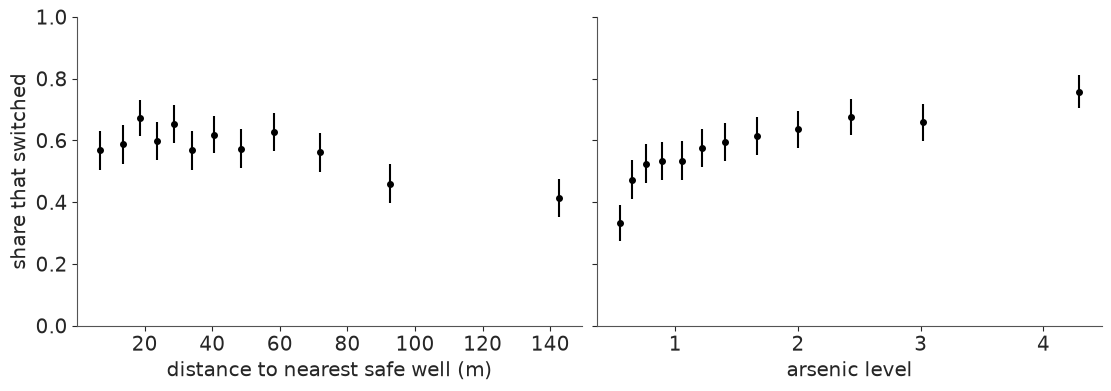

In [4]:
def binned_rate(x, y, n_bins=12):
    """Mean of y within quantile bins of x, with a +/- 2 standard error bar."""
    bins = pd.qcut(x, n_bins, duplicates="drop")
    g = pd.DataFrame({"x": x, "y": y}).groupby(bins, observed=True)
    out = g.agg(x=("x", "mean"), rate=("y", "mean"), n=("y", "size"))
    out["se"] = np.sqrt(out.rate * (1 - out.rate) / out.n)
    return out


fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, col, label in zip(axes, ["distance", "arsenic"], ["distance to nearest safe well (m)", "arsenic level"]):
    b = binned_rate(wells[col], wells.y)
    ax.errorbar(b.x, b.rate, yerr=2 * b.se, fmt="o", color="k", ms=4)
    ax.set(xlabel=label, ylim=(0, 1))
axes[0].set_ylabel("share that switched");

A scatter plot of a 0/1 outcome is two stripes of dots, so we plot the switching rate in
bins instead. Further to walk: less switching. More arsenic: more switching, but the
curve flattens - remember that for later.

## 2 · Scale the predictors before you think about priors

A prior is a statement about a coefficient, and a coefficient is "change in log-odds **per
unit of x**". In metres, the distance coefficient would be around -0.006: what prior is
"weakly informative" for that? Nobody knows without doing arithmetic. So change the units
until a coefficient of 1 is a **big but conceivable** effect:

- `dist100`: distance in units of 100 m (most households are within 100 m of a safe well).
- `educ4`: education in units of 4 years.
- arsenic is already of order 1.

We also **centre** every predictor. Then $\alpha$ is the log-odds of switching for an average
household - something we can reason about - instead of for a household with zero arsenic
living on top of a safe well, which does not exist. Centring also makes main effects
readable when we add interactions.

A model in this notebook is a list of terms; `"a:b"` means the product of two centred columns.

In [5]:
CENTRE = wells[["dist100", "arsenic", "log_arsenic", "educ4", "assoc"]].mean()


def design(df, terms):
    """Centred design matrix for a list of terms such as ["dist100", "arsenic", "dist100:arsenic"]."""
    Z = df[CENTRE.index] - CENTRE  # centred with the means of the OBSERVED data, always
    return pd.DataFrame({t: Z[t.split(":")].prod(axis=1) for t in terms}, index=df.index)


design(wells, ["dist100", "arsenic", "dist100:arsenic"]).head(3).round(3)

,dist100,arsenic,dist100:arsenic
rownames,,,
1,-0.315,0.703,-0.222
2,-0.010,-0.947,0.010
3,-0.274,0.413,-0.113


## 3 · The model, and what priors look like through a logit link

One function builds every model we fit today. The two prior scales are arguments because
we are about to compare two choices.

In [6]:
def logistic_model(X, y, sigma_alpha=1.5, sigma_beta=1.0):
    coords = {"predictor": list(X.columns), "obs": X.index}
    with pm.Model(coords=coords) as model:
        alpha = pm.Normal("alpha", 0, sigma_alpha)
        beta = pm.Normal("beta", 0, sigma_beta, dims="predictor")
        eta = alpha + pm.math.dot(X.values, beta)  # the linear predictor, on the log-odds scale
        pm.Bernoulli("switch", logit_p=eta, observed=y, dims="obs")  # logit_p applies the inverse link
    return model


X1 = design(wells, ["dist100"])
logistic_model(X1, wells.y)

"When in doubt, make the prior wide" is a fine instinct on the scale of the *outcome*. On
the logit scale it backfires. Let us simulate from a "vague" `Normal(0, 10)` on both
parameters and from the defaults above, and look at what each claims about **probabilities**.

Sampling: [alpha, beta, switch]


Sampling: [alpha, beta, switch]


'vague': sd 10 on both: 67% of prior mass on P < 1% or P > 99%
weakly informative: sd 1.5 and 1: 0% of prior mass on P < 1% or P > 99%


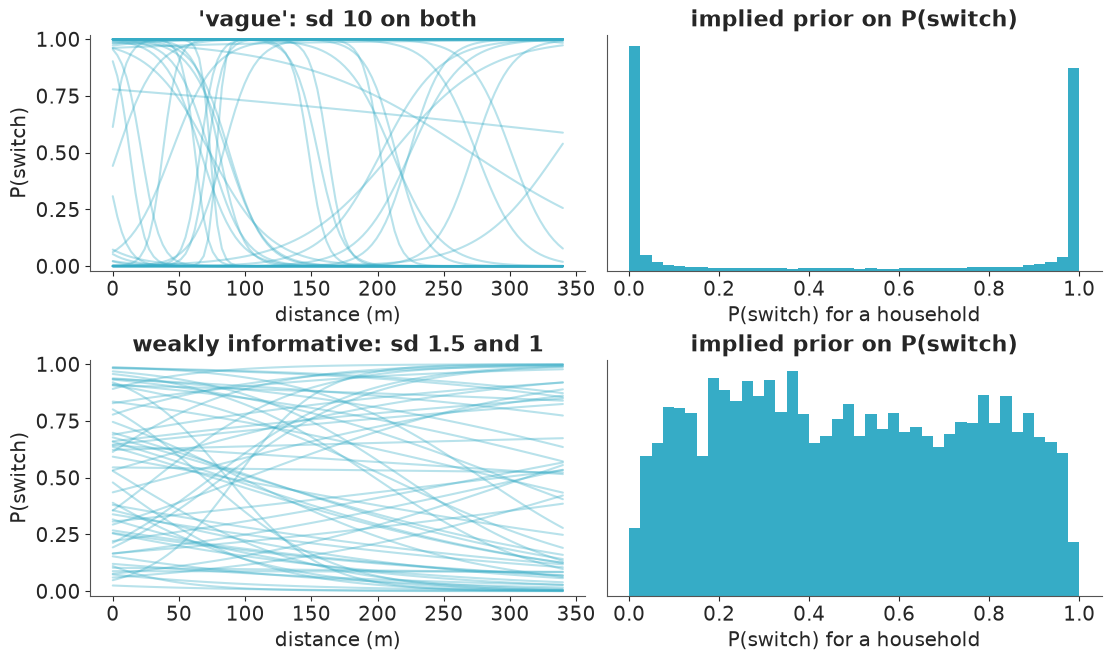

In [7]:
d_grid = np.linspace(0, 3.4, 100)  # distance grid in units of 100 m
priors = {"'vague': sd 10 on both": (10, 10), "weakly informative: sd 1.5 and 1": (1.5, 1.0)}

fig, axes = plt.subplots(2, 2, figsize=(11, 6.5))
for row, (label, (s_a, s_b)) in zip(axes, priors.items()):
    with logistic_model(X1, wells.y, s_a, s_b):
        prior_idata = pm.sample_prior_predictive(1000, random_seed=RANDOM_SEED)
    pr = az.extract(prior_idata, group="prior")
    a, b = pr["alpha"].values, pr["beta"].sel(predictor="dist100").values

    curves = expit(a[:, None] + b[:, None] * (d_grid - CENTRE["dist100"]))
    row[0].plot(d_grid * 100, curves[:60].T, color="C0", alpha=0.35)
    row[0].set(xlabel="distance (m)", ylabel="P(switch)", title=label, ylim=(-0.02, 1.02))

    # implied probability of switching for every household, pooled over prior draws
    p_households = expit(a[:, None] + b[:, None] * X1["dist100"].values)
    row[1].hist(p_households.ravel(), bins=40, density=True, color="C0")
    row[1].set(xlabel="P(switch) for a household", yticks=[], title="implied prior on P(switch)");
    print(f"{label}: {np.mean((p_households < 0.01) | (p_households > 0.99)):.0%} of prior mass on P < 1% or P > 99%")

The "vague" prior is anything but. A log-odds of ±10 is a probability of 0.00005 or
0.99995, so `Normal(0, 10)` says: *almost every household either certainly switches or
certainly does not, and moving a few metres flips the village from one to the other.* That is
a strong, bizarre belief - the prior on the probability scale is a bathtub, with two thirds
of its mass below 1% or above 99%.

The weakly-informative version spreads over the whole probability scale, allows steep
curves in both directions, and only rules out cliffs. With 3020 observations either prior
will be overwhelmed for the main effects. With few observations, rare outcomes, or perfectly
separating predictors it will not, and the bathtub prior actively hurts. **Always check
GLM priors on the outcome scale.**

## 4 · Fit, diagnose, interpret: distance only

The helper below samples, optionally adds posterior predictive draws (for the calibration
checks in section 7), and computes PSIS-LOO, which section 8 explains. LOO needs the pointwise
log-likelihood, a 4000 x 3020 array of about 100 MB per model. We fit five models, and a
notebook kernel never frees anything you still hold a name for, so the helper keeps the small
LOO result and **deletes the big array** straight away. On a laptop this is the difference
between a notebook that peaks above 3 GB and one that stays well under 2.

In [8]:
def fit(terms, ppc=False):
    """Fit a logistic model with these terms; return (DataTree, PSIS-LOO result)."""
    with logistic_model(design(wells, terms), wells.y):
        idata = pm.sample(random_seed=RANDOM_SEED)
        if ppc:
            pm.sample_posterior_predictive(idata, extend_inferencedata=True, random_seed=RANDOM_SEED)
        pm.compute_log_likelihood(idata, progressbar=False)  # pointwise log-likelihood, needed for LOO
    loo = az.loo(idata, pointwise=True)  # see section 8
    # Two ~100 MB arrays we no longer need: the log-likelihood that LOO has consumed, and the
    # importance weights that ArviZ keeps on the result (compare and plot_khat do not use them).
    del idata["log_likelihood"]
    loo.log_weights = None
    print("divergences:", int(idata.sample_stats["diverging"].sum()))
    return idata, loo


idatas, loos = {}, {}
idatas["dist"], loos["dist"] = fit(["dist100"])
az.summary(idatas["dist"], var_names=["alpha", "beta"], ci_kind="hdi", ci_prob=0.94, round_to=2)

NUTS[nutpie]: [alpha, beta]


divergences: 0


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,0.30,0.04,0.24,0.38,4282.75,2677.55,1.0,0.0,0.0
beta[dist100],-0.62,0.09,-0.79,-0.43,3998.01,2990.62,1.0,0.0,0.0


Diagnostics are clean (`r_hat` of 1.00, ESS in the thousands, no divergences), so we may
interpret.

**The intercept.** Predictors are centred, so `expit(alpha)` is the switching probability
for a household at the average distance of 48 m.

**The slope, and the divide-by-4 rule.** The logistic curve is steepest at $p = 0.5$, where
its slope is $\beta/4$. So $\beta / 4$ is an **upper bound** on the change in probability
per unit of $x$ - and a good approximation whenever probabilities are between roughly 0.25
and 0.75, as they are here.

In [9]:
post = idatas["dist"].posterior
beta_dist = post["beta"].sel(predictor="dist100")
print(f"P(switch) at average distance: {float(expit(post['alpha']).mean()):.2f}")
print(f"divide-by-4: 100 m further away lowers P(switch) by at most {-25 * float(beta_dist.mean()):.1f} percentage points")

P(switch) at average distance: 0.58
divide-by-4: 100 m further away lowers P(switch) by at most 15.5 percentage points


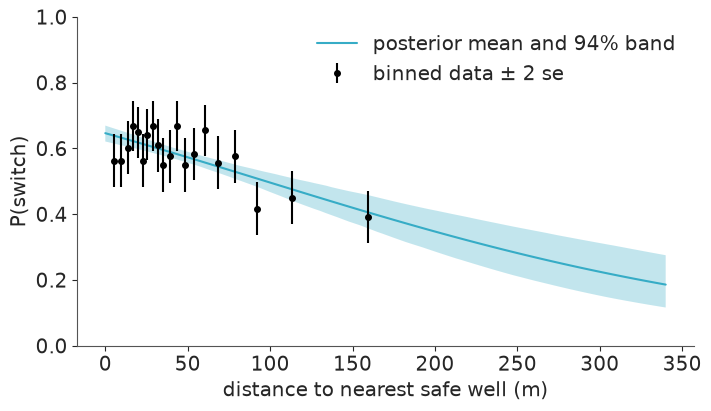

In [10]:
def predict_p(idata, X, num_samples=1000):
    """Posterior draws of P(switch) for the rows of a design matrix: array (draws, rows)."""
    draws = az.extract(idata, var_names=["alpha", "beta"], num_samples=num_samples, random_seed=RANDOM_SEED)
    beta = draws["beta"].transpose("sample", "predictor").values
    return expit(draws["alpha"].values[:, None] + beta @ X.values.T)


grid = prepare(pd.DataFrame({"distance": d_grid * 100, "arsenic": 1.0, "education": 0, "switch": "no", "association": "no"}))
p_grid = predict_p(idatas["dist"], design(grid, ["dist100"]))

b = binned_rate(wells.distance, wells.y, n_bins=20)
fig, ax = plt.subplots(figsize=(7, 4))
ax.fill_between(grid.distance, *np.quantile(p_grid, [0.03, 0.97], axis=0), alpha=0.3)
ax.plot(grid.distance, p_grid.mean(axis=0), label="posterior mean and 94% band")
ax.errorbar(b.x, b.rate, yerr=2 * b.se, fmt="o", color="k", ms=4, label="binned data ± 2 se")
ax.set(xlabel="distance to nearest safe well (m)", ylabel="P(switch)", ylim=(0, 1))
ax.legend();

## 5 · Add arsenic, then ask a better question than "what is beta?"

In [11]:
idatas["dist + arsenic"], loos["dist + arsenic"] = fit(["dist100", "arsenic"], ppc=True)
az.summary(idatas["dist + arsenic"], var_names=["alpha", "beta"], ci_kind="hdi", ci_prob=0.94, round_to=2)

NUTS[nutpie]: [alpha, beta]


Sampling: [switch]


divergences: 0


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,0.33,0.04,0.26,0.41,5354.40,2955.81,1.0,0.0,0.0
beta[dist100],-0.89,0.10,-1.09,-0.70,5671.24,3342.28,1.0,0.0,0.0
beta[arsenic],0.46,0.04,0.38,0.54,5050.81,3095.49,1.0,0.0,0.0


Both effects have the expected sign, and the distance coefficient became *more* negative
once arsenic entered (-0.62 before, -0.89 now). That happens when predictors are
correlated in the "masking" direction: households far from a safe well tend to have
somewhat higher arsenic (correlation 0.18, printed below), so in the distance-only model
the two effects partly cancelled.

Which predictor matters more? Coefficients cannot say: they are per unit, and "1 unit of
arsenic" and "100 m" are not comparable. They are also on the wrong scale. The planner's
question is about **probabilities**, and because of the non-linear link the effect of
distance on probability is different for every household.

The honest summary is an **average predictive difference**: take every household as it is,
set the predictor to a low value, then to a high value, leave everything else alone, and
average the change in predicted probability over households. Do it once per posterior draw
and you get a posterior distribution for the answer.

In [12]:
print(f"correlation of distance and arsenic: {wells.distance.corr(wells.arsenic):.2f}")


def average_predictive_difference(idata, terms, column, lo, hi):
    """Posterior draws of mean_i[ P(switch | column=hi, rest_i) - P(switch | column=lo, rest_i) ]."""
    p_lo = predict_p(idata, design(prepare(raw.assign(**{column: lo})), terms))
    p_hi = predict_p(idata, design(prepare(raw.assign(**{column: hi})), terms))
    return (p_hi - p_lo).mean(axis=1)


def report(apd, label):
    lo, hi = np.quantile(apd, [0.03, 0.97])
    print(f"{label:<42} {apd.mean():+.3f}   94% interval [{lo:+.3f}, {hi:+.3f}]")


terms = ["dist100", "arsenic"]
report(average_predictive_difference(idatas["dist + arsenic"], terms, "distance", 0, 100), "distance: next door -> 100 m away")
report(average_predictive_difference(idatas["dist + arsenic"], terms, "arsenic", 0.5, 1.0), "arsenic: 0.5 -> 1.0")
report(average_predictive_difference(idatas["dist + arsenic"], terms, "arsenic", 0.5, 2.0), "arsenic: 0.5 -> 2.0")

correlation of distance and arsenic: 0.18
distance: next door -> 100 m away          -0.204   94% interval [-0.246, -0.160]
arsenic: 0.5 -> 1.0                        +0.056   94% interval [+0.046, +0.066]
arsenic: 0.5 -> 2.0                        +0.166   94% interval [+0.137, +0.194]


Note the counterfactuals are set on the **raw** columns (`distance` in metres, `arsenic`)
and pushed through `prepare` and `design` again, so derived columns such as the logarithm
or an interaction stay consistent. Compare the first line with the divide-by-4 bound from
the coefficient in the table above (-0.89 / 4 = -0.22): close, and a little smaller, as it
must be.

## 6 · An interaction

Does distance put people off *less* when the arsenic level is frightening? That is an
interaction: the slope of one predictor depends on the value of another. With centred
inputs the main effects keep their meaning (the effect of distance *at average arsenic*).

In [13]:
idatas["dist * arsenic"], loos["dist * arsenic"] = fit(["dist100", "arsenic", "dist100:arsenic"])
az.summary(idatas["dist * arsenic"], var_names=["alpha", "beta"], ci_kind="hdi", ci_prob=0.94, round_to=2)

NUTS[nutpie]: [alpha, beta]


divergences: 0


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,0.35,0.04,0.28,0.43,5334.02,3156.34,1.0,0.0,0.0
beta[dist100],-0.87,0.11,-1.07,-0.68,5297.75,3337.16,1.0,0.0,0.0
beta[arsenic],0.47,0.04,0.39,0.55,4867.39,2869.04,1.0,0.0,0.0
beta[dist100:arsenic],-0.18,0.10,-0.37,0.01,5414.59,3463.53,1.0,0.0,0.0


In [14]:
inter = idatas["dist * arsenic"].posterior["beta"].sel(predictor="dist100:arsenic")
print(f"P(interaction < 0) = {float((inter < 0).mean()):.2f}")

P(interaction < 0) = 0.96


The interaction is probably negative, but the 94% interval is wide and just includes zero. Hold on
to that thought: whether this term *earns its place* is a model comparison question, and we
will get a quantitative answer in section 8.

## 7 · Posterior predictive checks that work for binary data

The standard density overlay (`az.plot_ppc_dist`) is useless here. The data are zeros and
ones; any model with an intercept reproduces the overall share of ones, so the check always
passes. Two checks that *can* fail:

### Calibration

When the model says 70%, do 70% of those households switch? `az.plot_ppc_pava` estimates
the conditional event probability as a function of the predicted probability (with
isotonic regression, the pool-adjacent-violators algorithm - so no arbitrary bins) and
compares it with the diagonal. The band shows where the curve could fall if the model were
perfectly calibrated.

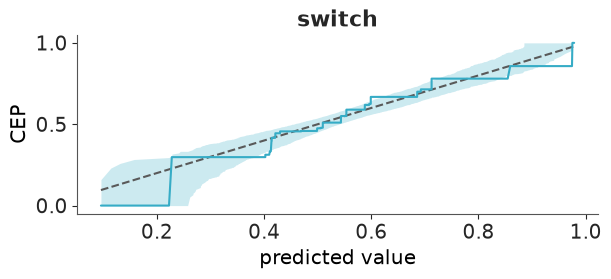

In [15]:
az.plot_ppc_pava(idatas["dist + arsenic"]);

The curve tracks the diagonal through the middle, but at both ends it hugs the edge of
the band. Look at the right: above predicted probabilities of about 0.85 it runs along
the lower edge - the households the model is most sure about switch a little less often
than promised. Suggestive rather than damning; we need a sharper tool.

### Binned residuals

Calibration plots show *that* something is off, not *where*. Raw residuals $y_i - \hat p_i$
of a binary model are unreadable (two stripes again). Average them within bins of a
predictor and they become informative: if the model is right, about 95% of the bin averages
should fall inside $\pm 2\sqrt{\bar p(1-\bar p)/n}$.

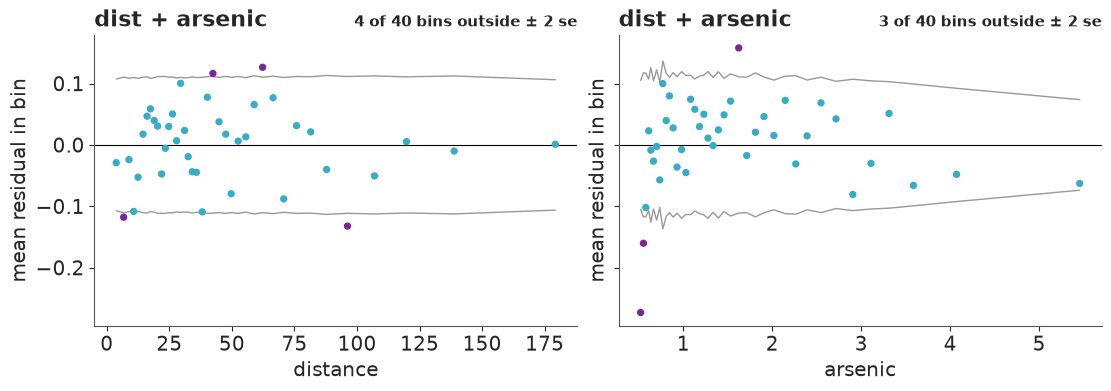

In [16]:
def plot_binned_residuals(idata, terms, column, ax, n_bins=40):
    p_hat = predict_p(idata, design(wells, terms)).mean(axis=0)
    df = pd.DataFrame({"x": wells[column], "resid": wells.y - p_hat, "var": p_hat * (1 - p_hat)})
    g = df.groupby(pd.qcut(df.x, n_bins, duplicates="drop"), observed=True)
    x, resid, bound = g.x.mean(), g.resid.mean(), 2 * np.sqrt(g["var"].mean() / g.size())
    outside = np.abs(resid) > bound
    ax.plot(x, bound, color="0.6", lw=1)
    ax.plot(x, -bound, color="0.6", lw=1)
    ax.axhline(0, color="k", lw=0.8)
    ax.scatter(x, resid, c=np.where(outside, "C3", "C0"), s=18, zorder=3)
    ax.set(xlabel=column, ylabel="mean residual in bin")
    ax.set_title(f"{int(outside.sum())} of {len(x)} bins outside ± 2 se", loc="right", fontsize=11)


fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, column in zip(axes, ["distance", "arsenic"]):
    plot_binned_residuals(idatas["dist + arsenic"], ["dist100", "arsenic"], column, ax)
    ax.set_title("dist + arsenic", loc="left")

Against distance the residuals look like noise: four bins poke just outside the bounds
where chance alone would give about two of 40, but their signs alternate and there is no
trend. Against **arsenic** there is a pattern: the three lowest-arsenic bins are negative,
the first of them by 27 percentage points (the model predicts more switching than happens
among households barely over the limit), the middle is mostly positive, and five of the
six highest bins are negative again. A straight line in arsenic rises too slowly at first
and too fast later - the signature of **diminishing returns**, which is what the very
first plot hinted at. The standard fix is to put arsenic on the log scale: going from 0.5
to 1 then matters as much as going from 2 to 4.

NUTS[nutpie]: [alpha, beta]


Sampling: [switch]


divergences: 0


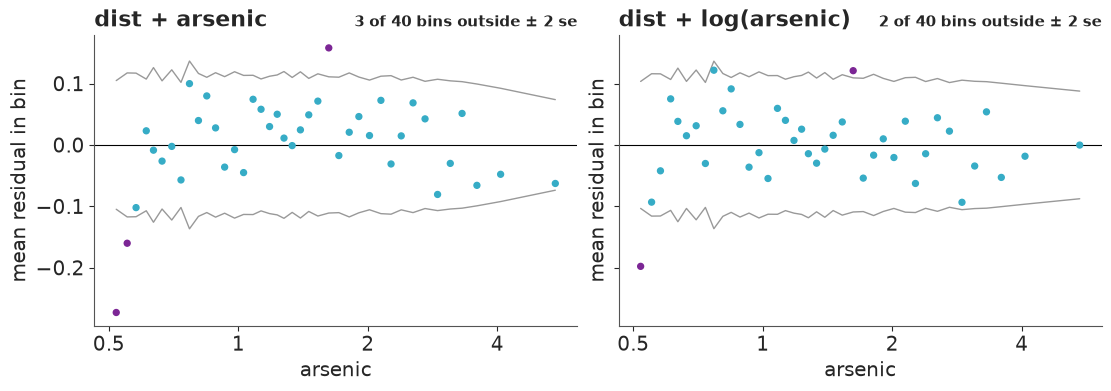

In [17]:
idatas["dist + log(arsenic)"], loos["dist + log(arsenic)"] = fit(["dist100", "log_arsenic"], ppc=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, (name, terms) in zip(axes, {"dist + arsenic": ["dist100", "arsenic"], "dist + log(arsenic)": ["dist100", "log_arsenic"]}.items()):
    plot_binned_residuals(idatas[name], terms, "arsenic", ax)
    ax.set_title(name, loc="left")
    ax.set_xscale("log")
    ax.set_xticks([0.5, 1, 2, 4], ["0.5", "1", "2", "4"], minor=False)
    ax.set_xticks([], minor=True)

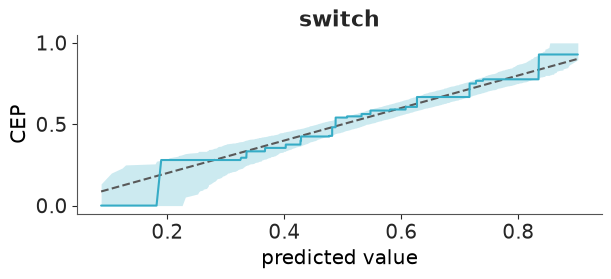

In [18]:
az.plot_ppc_pava(idatas["dist + log(arsenic)"]);

Better, not perfect. The wave in the residuals has gone and the calibration curve now
stays inside its band at the top end, but the very first bin - households just above the
safety limit - still switches far less than the model expects. (Gelman & Hill suspect a
psychological threshold: "barely unsafe" does not feel unsafe. A smooth function of
arsenic cannot capture that.)

One more step before comparing everything: education and community association, and whether
education changes how people respond to distance.

In [19]:
full_terms = ["dist100", "log_arsenic", "educ4", "assoc", "dist100:educ4"]
idatas["full"], loos["full"] = fit(full_terms)
az.summary(idatas["full"], var_names=["alpha", "beta"], ci_kind="hdi", ci_prob=0.94, round_to=2)

NUTS[nutpie]: [alpha, beta]


divergences: 0


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,0.33,0.04,0.26,0.41,5211.42,3208.32,1.0,0.0,0.0
beta[dist100],-1.00,0.11,-1.19,-0.80,4371.85,3502.76,1.0,0.0,0.0
beta[log_arsenic],0.90,0.07,0.76,1.02,4818.07,3505.41,1.0,0.0,0.0
beta[educ4],0.18,0.04,0.10,0.25,6249.08,3613.97,1.0,0.0,0.0
beta[assoc],-0.13,0.08,-0.28,0.01,5333.35,3537.30,1.0,0.0,0.0
beta[dist100:educ4],0.38,0.10,0.18,0.56,5689.11,3407.18,1.0,0.0,0.0


## 8 · Model comparison with PSIS-LOO

We have five models. Binned residuals told us *how* some of them fail; LOO tells us how
much that matters for **predicting households we have not seen**.

The quantity being estimated is the expected log pointwise predictive density, **elpd**:
the sum over observations of the log probability the model assigns to $y_i$ when $y_i$
was *not* used for fitting. Refitting 3020 times is out of the question, so PSIS-LOO
re-weights the draws of the one posterior you have (Pareto-smoothed importance sampling).
That is still the slow step of this notebook (a 4000 x 3020 matrix of weights to smooth per
model), so the `fit` helper computed it **once** per model, as `az.loo(idata, pointwise=True)`,
and kept only the result; `az.compare` accepts those results in place of the `DataTree`s.
`pointwise=True` keeps the per-household values, which we will want later. Start by reading
a single model:

In [20]:
loo_full = loos["full"]
loo_full

Computed from 4000 posterior samples and 3020 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1936.88    17.07
p_loo        6.07        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     3020  100.0%
   (0.70, 1]   (bad)         0    0.0%
    (1, Inf)   (very bad)    0    0.0%

How to read this:

- **`elpd_loo`** is only meaningful relative to another model on the *same data*. Higher
  (less negative) is better. For scale: a coin flip would score
  $3020 \times \log 0.5 \approx -2093$.
- **`p_loo`** is the effective number of parameters. Here it is close to the actual count
  (six coefficients), as it should be for a well-specified model with weak priors. A
  `p_loo` far above the parameter count is a warning sign of misspecification.
- **Pareto $k$** is a per-observation reliability diagnostic for the importance sampling
  itself. $k < 0.7$: fine. Larger: that observation is so influential that removing it
  changes the posterior more than re-weighting can mimic, and the elpd estimate cannot be
  trusted. With 3020 observations and six parameters no single household is influential,
  so every $k$ is tiny. (You will meet bad ones in the challenges - they usually point at
  outliers or at an over-flexible model.)

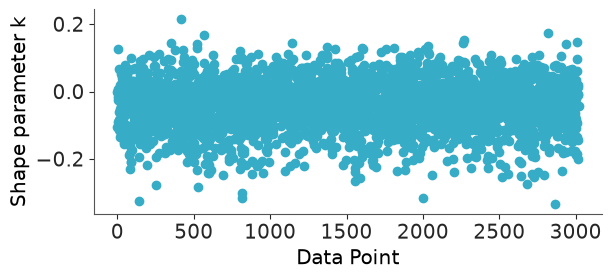

In [21]:
az.plot_khat(loo_full);

In [22]:
comparison = az.compare(loos, round_to=1)
comparison

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
full,0,0.0,0.0,NaN,,,6.1,-1936.9,17.1,0.9
dist + log(arsenic),1,-15.3,6.1,1.0,,,3.1,-1952.2,16.2,0.1
dist * arsenic,2,-31.2,7.7,1.0,,,4.4,-1968.1,15.8,0.0
dist + arsenic,3,-31.7,7.7,1.0,,,3.4,-1968.6,15.6,0.0
dist,4,-103.2,14.2,1.0,,,1.9,-2040.0,10.4,0.0


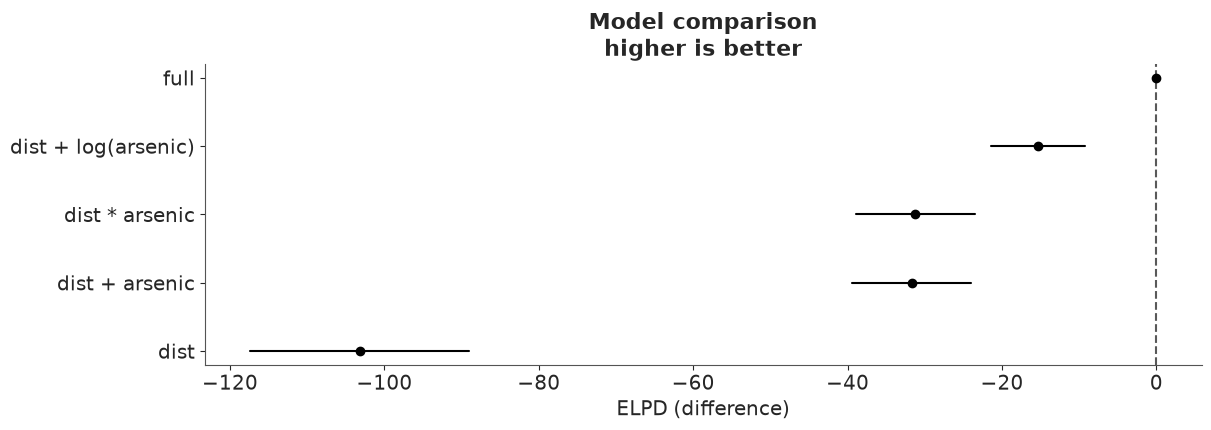

In [23]:
az.plot_compare(comparison);

Reading the table:

- Rows are sorted best first. **`elpd_diff`** is each model's elpd minus the best model's;
  `p` is `p_loo`.
- **`dse`** is the standard error *of that difference*. It is not derived from the two `se`
  columns: the pointwise elpd values of two models on the same data are highly correlated
  (a household that is hard to predict is hard for both), so the difference is known far
  more precisely than either total. **Always compare `elpd_diff` with `dse`, never with
  `se`.**
- Rules of thumb: a difference under about 4 is too small to care about whatever its `dse`;
  beyond that, take it seriously when it is several `dse` from zero. `p_worse` turns the
  pair into a probability under a normal approximation - treat it as a rough guide.
- `dse` is always **relative to the top row**. To compare two models further down, call
  `az.compare` on just those two, as we do below.
- **`weight`** is a stacking weight: how to mix the models' predictions to predict best.
  It is *not* a posterior probability that the model is true. Near-duplicates share or lose
  weight arbitrarily.

In [24]:
pairs = [("dist + arsenic", "dist * arsenic"), ("dist + arsenic", "dist + log(arsenic)")]
pd.concat([az.compare({k: loos[k] for k in pair}, round_to=1)[["elpd_diff", "dse", "p"]] for pair in pairs])

,elpd_diff,dse,p
dist * arsenic,0.0,0.0,4.4
dist + arsenic,-0.5,1.9,3.4
dist + log(arsenic),0.0,0.0,3.1
dist + arsenic,-16.4,4.4,3.4


What all this says:

1. Adding arsenic to distance is a huge improvement (about 70 elpd).
2. The **log** transformation beats raw arsenic by about 16 elpd, almost four times its `dse`,
   with the same number of parameters. LOO agrees with the binned residuals.
3. The **distance x arsenic interaction** buys nothing: half a unit of elpd, a fraction of
   its `dse`, for one extra parameter. A coefficient with a 96% posterior probability of
   being negative can still be irrelevant for prediction. Drop it, unless the interaction
   itself is the scientific question.
4. The full model is best: 15 elpd ahead of the runner-up, about 2.5 `dse`. Convincing, if
   not overwhelming.

LOO also works pointwise, which makes it a diagnostic rather than only a scoreboard. Where
does the log model gain over the linear one?

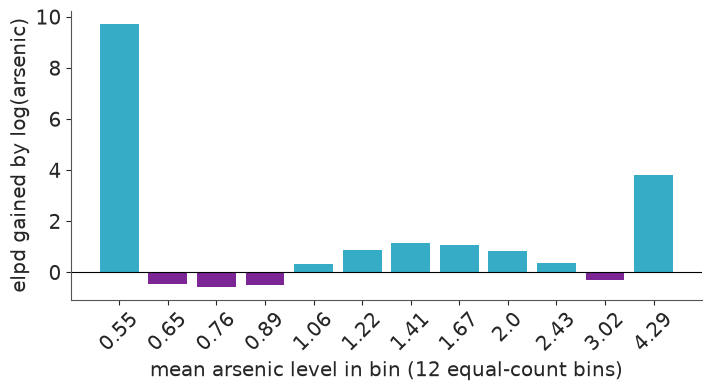

In [25]:
elpd_lin, elpd_log = loos["dist + arsenic"].elpd_i, loos["dist + log(arsenic)"].elpd_i
gain = pd.DataFrame({"arsenic": wells.arsenic.values, "gain": (elpd_log - elpd_lin).values})
by_bin = gain.groupby(pd.qcut(gain.arsenic, 12), observed=True).agg(arsenic=("arsenic", "mean"), gain=("gain", "sum"))

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.bar(range(len(by_bin)), by_bin.gain, color=np.where(by_bin.gain > 0, "C0", "C3"))
ax.set_xticks(range(len(by_bin)), by_bin.arsenic.round(2), rotation=45)
ax.axhline(0, color="k", lw=0.8)
ax.set(xlabel="mean arsenic level in bin (12 equal-count bins)", ylabel="elpd gained by log(arsenic)");

Most of the gain - roughly 13 of the 16 units - comes from the two end bins: the
barely-unsafe wells and the most contaminated ones, exactly where the binned residuals of
the linear model were negative. In between, each bin moves by about one unit or less in
either direction: there the two models predict almost equally well.

## 9 · Answer the planner

Back to probabilities, with the best model. The interaction with education makes "the
effect of distance" depend on who you ask, which is precisely the situation average
predictive differences are built for.

In [26]:
report(average_predictive_difference(idatas["full"], full_terms, "distance", 0, 100), "distance: next door -> 100 m away")
report(average_predictive_difference(idatas["full"], full_terms, "arsenic", 0.5, 1.0), "arsenic: 0.5 -> 1.0")
report(average_predictive_difference(idatas["full"], full_terms, "arsenic", 1.0, 2.0), "arsenic: 1.0 -> 2.0")
report(average_predictive_difference(idatas["full"], full_terms, "education", 0, 12), "education: none -> 12 years")
report(average_predictive_difference(idatas["full"], full_terms, "association", "no", "yes"), "community association: no -> yes")

distance: next door -> 100 m away          -0.222   94% interval [-0.267, -0.179]
arsenic: 0.5 -> 1.0                        +0.146   94% interval [+0.126, +0.164]
arsenic: 1.0 -> 2.0                        +0.143   94% interval [+0.123, +0.161]
education: none -> 12 years                +0.118   94% interval [+0.068, +0.165]
community association: no -> yes           -0.031   94% interval [-0.066, +0.002]


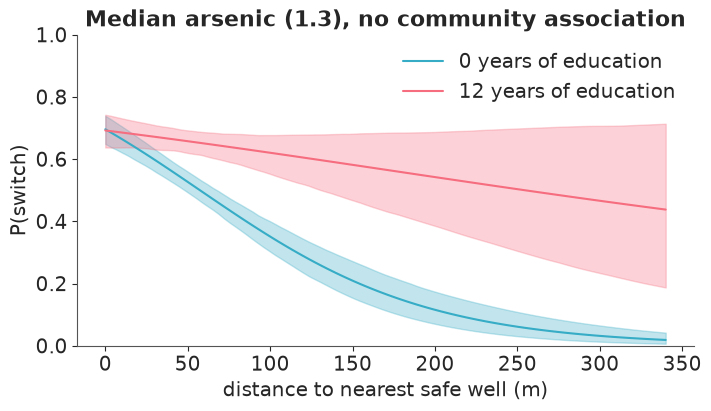

In [27]:
fig, ax = plt.subplots(figsize=(7, 4))
for color, years in zip(["C0", "C1"], [0, 12]):
    g = prepare(grid.assign(arsenic=wells.arsenic.median(), education=years))
    p = predict_p(idatas["full"], design(g, full_terms))
    ax.fill_between(g.distance, *np.quantile(p, [0.03, 0.97], axis=0), color=color, alpha=0.3)
    ax.plot(g.distance, p.mean(axis=0), color=color, label=f"{years} years of education")
ax.set(xlabel="distance to nearest safe well (m)", ylabel="P(switch)", ylim=(0, 1),
       title=f"Median arsenic ({wells.arsenic.median():.1f}), no community association")
ax.legend();

For a planner:

- Having to walk 100 m instead of next door lowers the switching probability by about 22
  percentage points on average. The deterrent is strongest among the least educated; with
  12 years of schooling the curve is much flatter (and, with few such households far from
  a safe well, much less certain). New safe wells are worth most where the nearest
  alternative is far away *and* education is low.
- The choice of scale for arsenic was not a technicality. The linear model put the effect of
  going from 0.5 to 1.0 at under 6 percentage points; the log model says 15 - the same as
  going from 1.0 to 2.0. The better-fitting model tells a different story about who responds
  to information.
- The surprise is community association: if anything its members switch **less**, though
  the interval reaches zero.

A caution the model cannot give you: this is an observational survey. "Setting distance to
0" in a computation is not the same as drilling a well next door; calling a predictive
difference *causal* takes assumptions that no amount of LOO can check.

### Try it yourself

1. Refit the distance-only model with the `Normal(0, 10)` priors on **all 3020** households
   and then on a random subsample of **30**. How much do the two priors disagree in each case?
   Plot the posterior curves for both.
2. The binned residuals still show too few switchers just above the safety limit. Add a term
   that lets the model treat "barely unsafe" wells differently (for example an indicator for
   `arsenic < 0.6`, or a spline in log arsenic) and compare with `az.compare`. Is the
   improvement worth a parameter nobody can interpret?
3. Swap the link: replace `logit_p=eta` with `p=pm.math.invprobit(eta)`. Coefficients shrink
   by a factor of about 1.6 - do the average predictive differences change? Does LOO care?

Next: challenge **C03** moves from binary outcomes to counts, and gives LOO's Pareto-$k$
diagnostic real work to do.